In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('titanic.csv')
print("数据形状:", df.shape)
print("\n=== head ===\n", df.head())
print("\n=== info ===")
df.info()
print("\n=== describe ===\n", df.describe())


数据形状: (891, 12)

=== head ===
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3734

In [2]:
# === 数据清洗 ===

# 1. 先看一下各列缺失情况
print("各列缺失值数量:")
print(df.isnull().sum())

# 2. Age（年龄）：用中位数填充缺失值
df['Age'].fillna(df['Age'].median(), inplace=True)

# 3. Embarked（登船港）：缺了2个，用最常见的港口填充
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. Cabin（船舱号）：缺了太多（687个），直接删掉这列
df.drop('Cabin', axis=1, inplace=True)

# 5. 验证一下：现在是不是没缺失值了
print("\n清洗后缺失值数量:")
print(df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']].isnull().sum())


各列缺失值数量:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

清洗后缺失值数量:
Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64


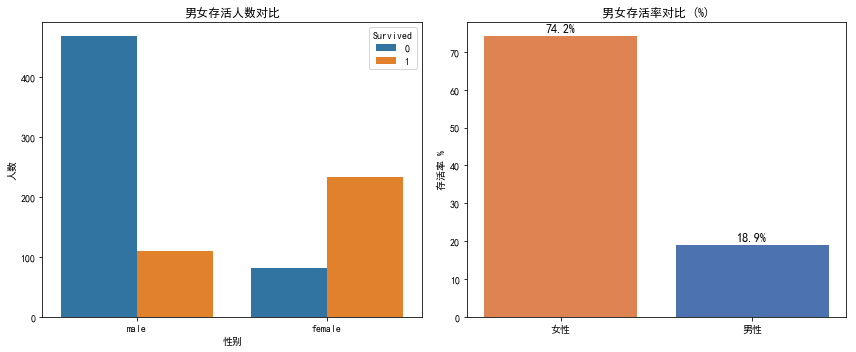

In [3]:
# === 性别与存活 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：男女存活人数对比
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('男女存活人数对比')
axes[0].set_xlabel('性别')
axes[0].set_ylabel('人数')

# 右图：男女存活率（百分比）
sex_survive_rate = df.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(['女性', '男性'], sex_survive_rate.values, color=['#DD8452', '#4C72B0'])
axes[1].set_title('男女存活率对比 (%)')
axes[1].set_ylabel('存活率 %')

# 在柱子上标数字
for i, v in enumerate(sex_survive_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


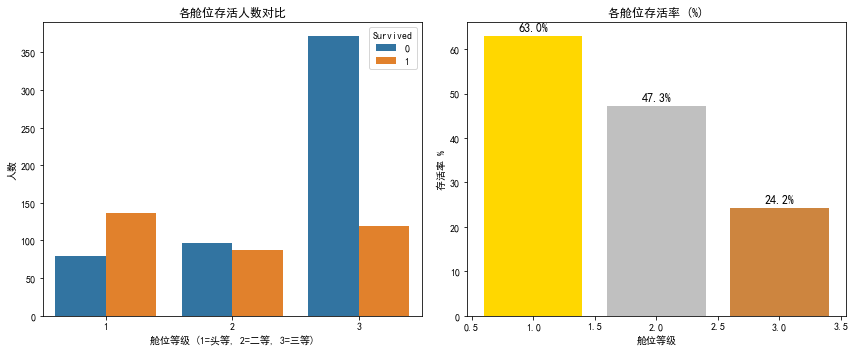

In [4]:
# === 舱位等级与存活 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：各等级存活人数
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('各舱位存活人数对比')
axes[0].set_xlabel('舱位等级 (1=头等, 2=二等, 3=三等)')
axes[0].set_ylabel('人数')

# 右图：各等级存活率
pclass_survive = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar([1, 2, 3], pclass_survive.values, color=['gold', 'silver', '#CD853F'])
axes[1].set_title('各舱位存活率 (%)')
axes[1].set_xlabel('舱位等级')
axes[1].set_ylabel('存活率 %')

for i, v in enumerate(pclass_survive.values):
    axes[1].text(i+1, v + 1, f'{v:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


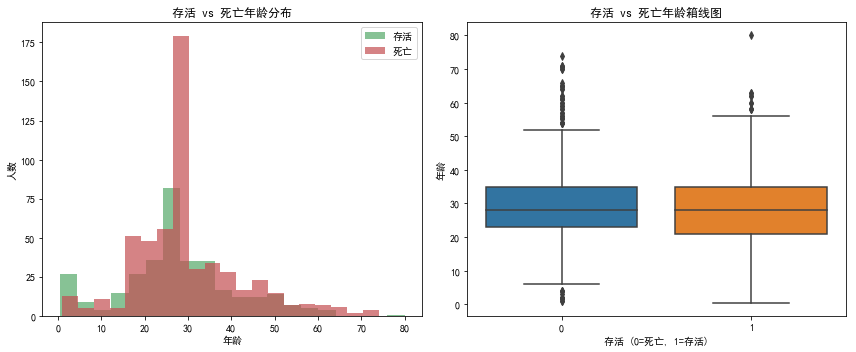

In [5]:
# === 年龄与存活 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：存活者 vs 死亡者的年龄分布
df_survived = df[df['Survived'] == 1]
df_died = df[df['Survived'] == 0]

axes[0].hist(df_survived['Age'], bins=20, alpha=0.7, label='存活', color='#55A868')
axes[0].hist(df_died['Age'], bins=20, alpha=0.7, label='死亡', color='#C44E52')
axes[0].set_title('存活 vs 死亡年龄分布')
axes[0].set_xlabel('年龄')
axes[0].set_ylabel('人数')
axes[0].legend()

# 右图：箱线图
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1])
axes[1].set_title('存活 vs 死亡年龄箱线图')
axes[1].set_xlabel('存活 (0=死亡, 1=存活)')
axes[1].set_ylabel('年龄')

plt.tight_layout()
plt.show()


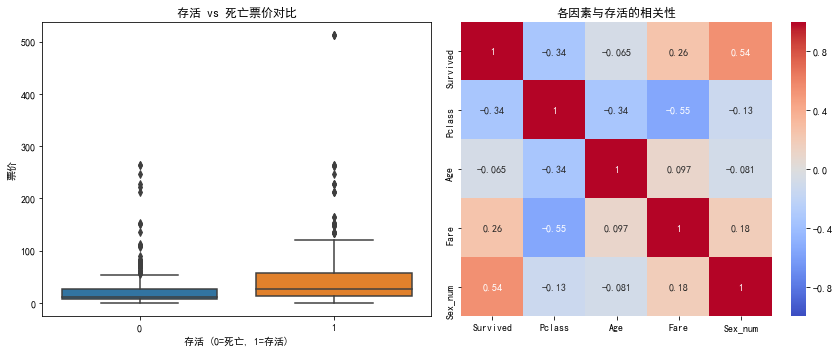

In [6]:
# === 票价与存活 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：箱线图
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[0])
axes[0].set_title('存活 vs 死亡票价对比')
axes[0].set_xlabel('存活 (0=死亡, 1=存活)')
axes[0].set_ylabel('票价')

# 右图：相关性热力图（把性别转成数字）
df_temp = df.copy()
df_temp['Sex_num'] = df_temp['Sex'].map({'male': 0, 'female': 1})

corr = df_temp[['Survived', 'Pclass', 'Age', 'Fare', 'Sex_num']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('各因素与存活的相关性')

plt.tight_layout()
plt.show()
